In [2]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('hourly_data.csv')

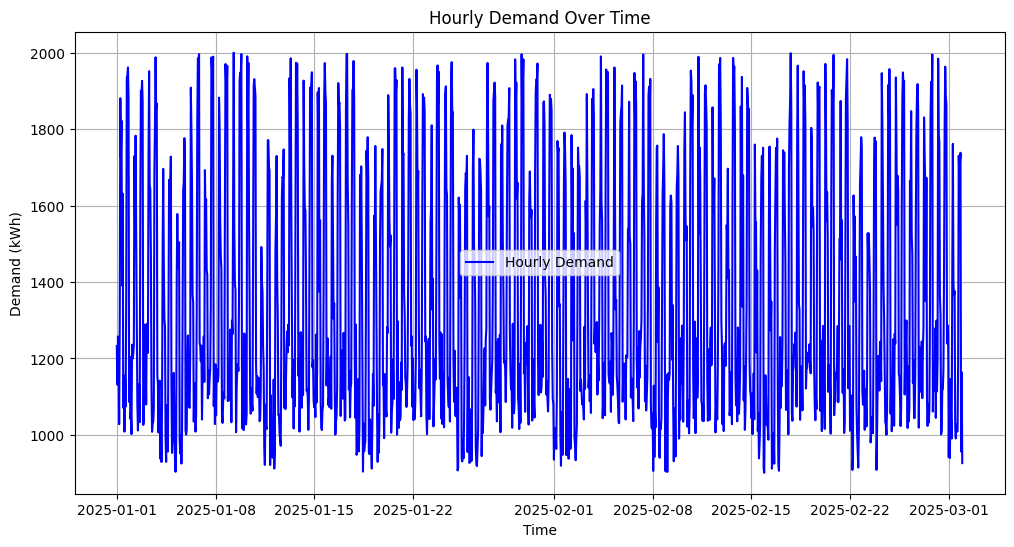

In [11]:
#EDA analysis 
# 1. demand over time
plt.figure(figsize=(12,6))
plt.plot(df['Timestamp'], df['Demand'], label='Hourly Demand', color='blue')
plt.xlabel('Time')
plt.ylabel('Demand (kWh)')
plt.title('Hourly Demand Over Time')
plt.grid(True)
plt.legend()
plt.show()

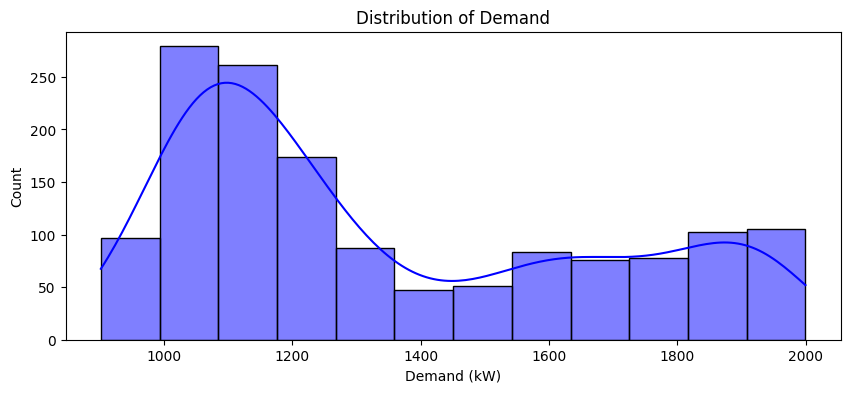

In [5]:
# 4. distribution plots
#   4.1 demand distribution
plt.figure(figsize=(10,4))
sns.histplot(df['Demand'], kde=True, color='blue')
plt.title("Distribution of Demand")
plt.xlabel("Demand (kW)")
plt.show()

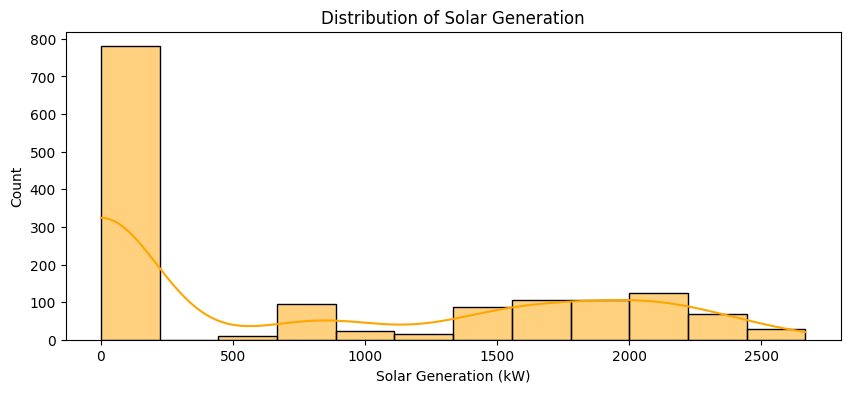

In [6]:
# 4.2 solar generation distribution
plt.figure(figsize=(10,4))
sns.histplot(df['Solar_Gen'], kde=True, color='orange')
plt.title("Distribution of Solar Generation")
plt.xlabel("Solar Generation (kW)")
plt.show()

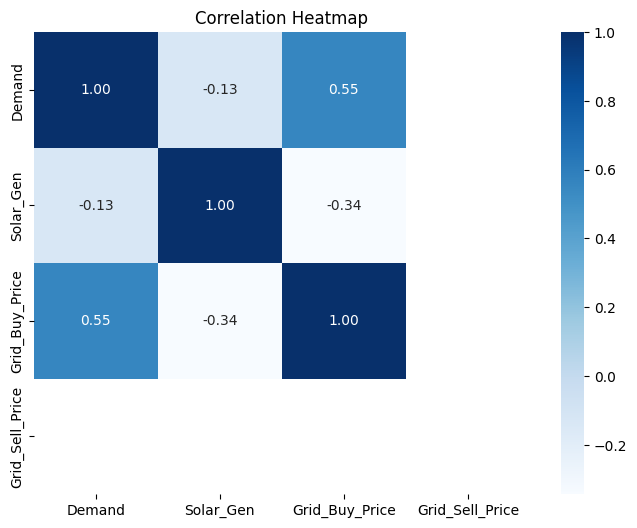

In [7]:
# 5. Correlation heatmap
plt.figure(figsize=(8,6))
corr = df[['Demand', 'Solar_Gen', 'Grid_Buy_Price', 'Grid_Sell_Price']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

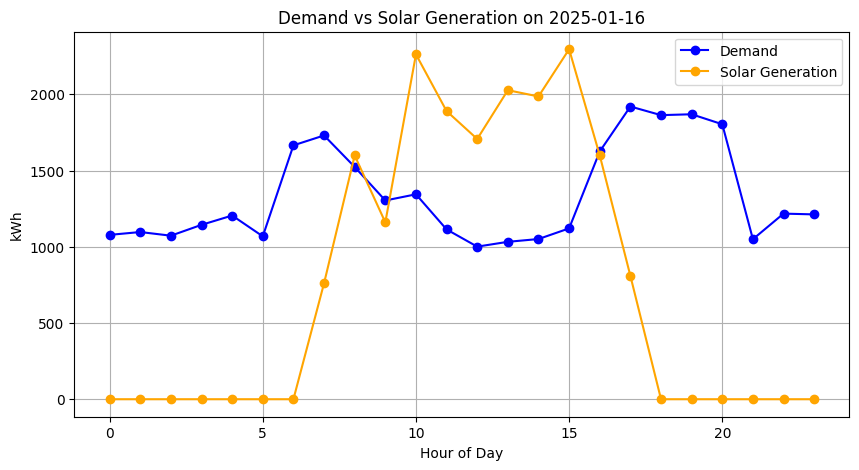

In [8]:
import random
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
all_days = df['Timestamp'].dt.date.unique()
random_day = random.choice(all_days)
one_day = df[df['Timestamp'].dt.date == random_day]

plt.figure(figsize=(10,5))
plt.plot(one_day['Timestamp'].dt.hour, one_day['Demand'], label='Demand', color='blue', marker='o')
plt.plot(one_day['Timestamp'].dt.hour, one_day['Solar_Gen'], label='Solar Generation', color='orange', marker='o')
plt.xlabel('Hour of Day')
plt.ylabel('kWh')
plt.title(f'Demand vs Solar Generation on {random_day}')
plt.legend()
plt.grid(True)
plt.show()

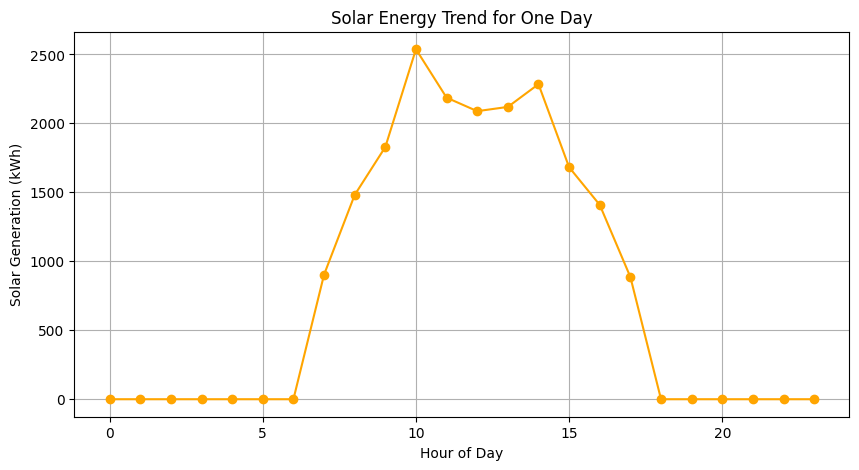

In [9]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Plot solar energy trend for one day, x-axis as hour
one_day = df[df['Timestamp'].dt.date == df['Timestamp'].dt.date.iloc[0]]
plt.figure(figsize=(10,5))
plt.plot(one_day['Timestamp'].dt.hour, one_day['Solar_Gen'], marker='o', color='orange')
plt.xlabel('Hour of Day')
plt.ylabel('Solar Generation (kWh)')
plt.title('Solar Energy Trend for One Day')
plt.grid(True)
plt.show()